In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH
from nrem_sc.utils import plot_intervals

import re
import numpy as np
import pynapple as nap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

unit_id = '116b'
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)
palette = ["#d73939", "#1d0505ff"]

# Load data
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
sweep_epochs = nap.load_file(r"D:\common_datasets\ucsf\processed\116b\post_ttx_nrem_epochs.npz")

In [2]:
save_dir = PROCESSED_DATA_PATH / unit_id / "post_ttx"
paths = list(save_dir.glob("*.npz"))
tdf = nap.load_file(paths[0])
tdf

Time (s)       continuous    fragmented    stationary    position
-----------  ------------  ------------  ------------  ----------
22244.24395      0.265459    0.0116501       0.722891    309.496
22244.24495      0.265196    0.0104668       0.724337    309.496
22244.24595      0.264924    0.00930605      0.72577     309.496
22244.24695      0.264645    0.00816741      0.727188    309.496
22244.24795      0.264357    0.00705036      0.728593    309.496
22244.24895      0.264061    0.00595441      0.729985    309.496
22244.24995      0.263758    0.00487905      0.731363    309.496
...
23244.23695      0.662881    0.0017236       0.335396     11.4999
23244.23795      0.662332    0.00186961      0.335799     11.4999
23244.23895      0.661791    0.00201449      0.336194     11.4999
23244.23995      0.661259    0.00215832      0.336583     11.4999
23244.24095      0.660734    0.0023012       0.336964     11.4999
23244.24195      0.660218    0.00244323      0.337339     11.4999
23244.24295  

In [3]:
pref_angle = hd_spikes['preferred_angle'].apply(np.rad2deg)
# Normalizes data into the range [0,1]
norm = plt.Normalize()
# Assigns a color in the HSV colormap for each value of preferred angle
color = plt.cm.hsv(norm([i / (2 * np.pi) for i in pref_angle.values]))

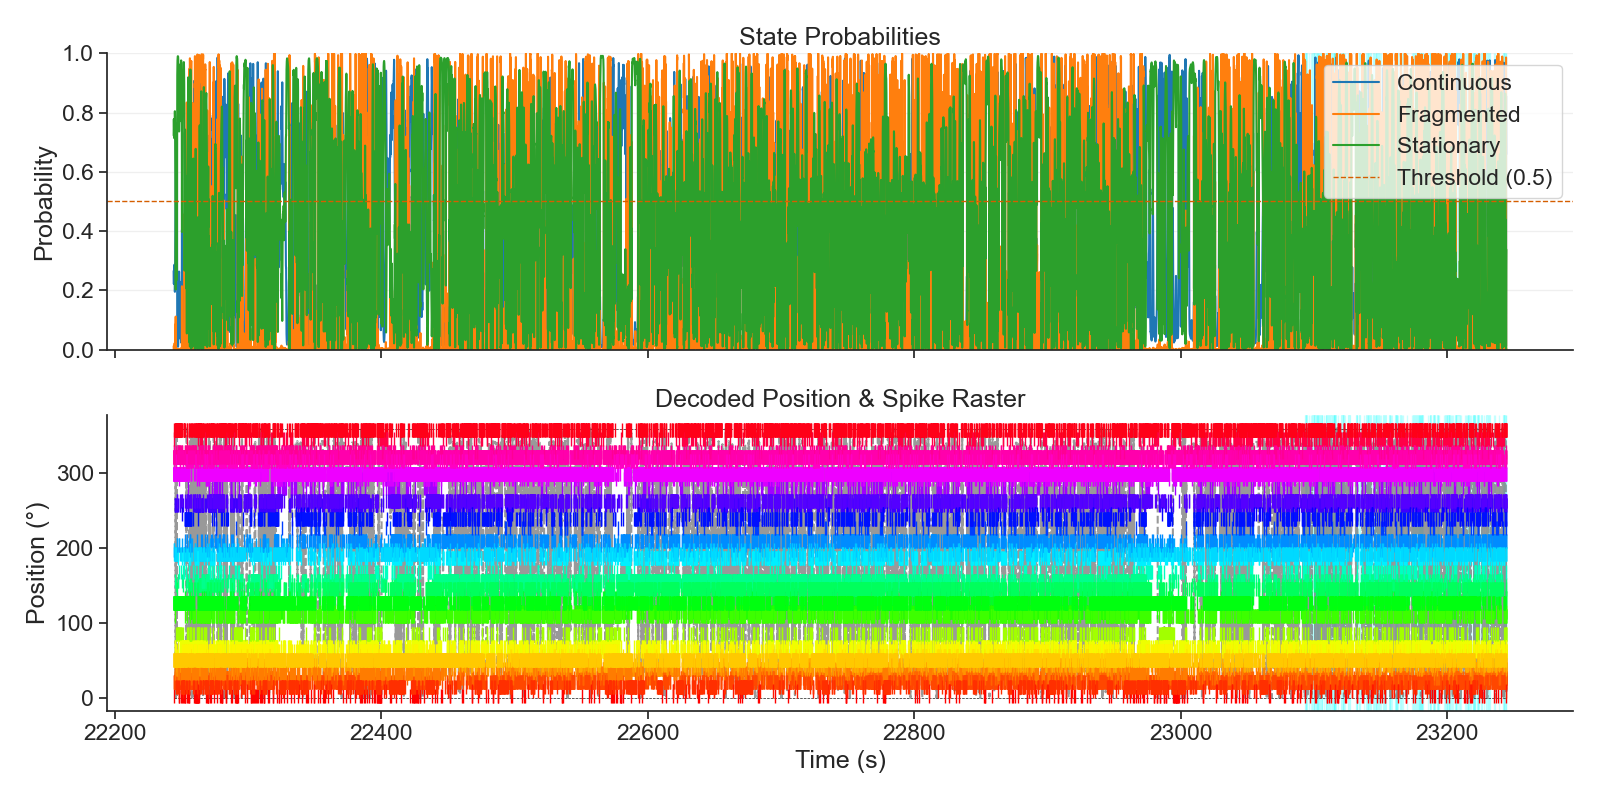

In [4]:
%matplotlib ipympl
sweep_threshold = 0.5
window = tdf.time_support
eps = sweep_epochs.intersect(window)
spikes = hd_spikes.restrict(window)

fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# state probabilities
ax[0].plot(tdf.times(), tdf['continuous'], label='Continuous', color='tab:blue')
ax[0].plot(tdf.times(), tdf['fragmented'], label='Fragmented', color='tab:orange')
ax[0].plot(tdf.times(), tdf['stationary'], label='Stationary', color='tab:green')
ax[0].axhline(sweep_threshold, color='r', linestyle='--', linewidth=1, label=f'Threshold ({sweep_threshold})')
ax[0].set_ylim(0, 1)
ax[0].set_ylabel('Probability')
ax[0].set_title('State Probabilities')
ax[0].legend(loc='upper right')
ax[0].grid(axis='y', alpha=0.3)

# decoded position + spike raster
ax[1].plot(tdf['position'], label='Decoded Position', color='gray', alpha=0.8, linestyle='--')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Position (°)')
ax[1].set_title('Decoded Position & Spike Raster')
ax[1].hlines([0, 359], color='k', xmin=tdf.times().min(), xmax=tdf.times().max(), linestyle='--', linewidth=0.5)

for i, n in enumerate(spikes.keys()):
    ax[1].plot(spikes[n].fillna(pref_angle[n].item()), '|', color=color[i], markersize=10)

# Highlight detected sweep epochs
for ep in eps:
    for a in ax:
        a.axvspan(ep['start'].item(), ep['end'].item(), color='cyan', alpha=0.2)

plt.tight_layout()
plt.show()